# Данные о поездках на желтых такси в Нью-Йорке

### Подключене библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

### Подключение стилей

In [37]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

### Загрузка данных

In [3]:
df = pd.read_csv('Book1.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк данных:")
df.head()

Размер датасета: (1382, 19)

Первые 5 строк данных:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,1/15/2015 19:05,1/15/2015 19:23,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,1/10/2015 20:33,1/10/2015 20:53,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,1/10/2015 20:33,1/10/2015 20:43,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,1/10/2015 20:33,1/10/2015 20:35,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,1/10/2015 20:33,1/10/2015 20:52,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [4]:
print("Информация о датасете:")
df.info()

print("\nСтатистическое описание числовых признаков:")
df.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1382 entries, 0 to 1381
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               1382 non-null   int64  
 1   tpep_pickup_datetime   1382 non-null   object 
 2   tpep_dropoff_datetime  1382 non-null   object 
 3   passenger_count        1382 non-null   int64  
 4   trip_distance          1382 non-null   float64
 5   pickup_longitude       1382 non-null   float64
 6   pickup_latitude        1382 non-null   float64
 7   RateCodeID             1382 non-null   int64  
 8   store_and_fwd_flag     1382 non-null   object 
 9   dropoff_longitude      1382 non-null   float64
 10  dropoff_latitude       1382 non-null   float64
 11  payment_type           1382 non-null   int64  
 12  fare_amount            1382 non-null   float64
 13  extra                  1382 non-null   float64
 14  mta_tax                1382 non-n

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1382.000000,1.382000e+03,1382.000000
mean,1.530391,1.669320,2.841599,-72.688864,40.041969,1.036903,-72.799244,40.103068,1.316208,12.283285,0.438133,0.498915,1.746418,0.254747,3.000000e-01,15.521498
std,0.499256,1.285433,3.602672,9.666839,5.325180,0.291216,9.262499,5.102531,0.471349,10.853923,0.193037,0.023279,2.219990,1.310679,7.219062e-15,12.941514
min,1.000000,1.000000,0.000000,-74.016266,0.000000,1.000000,-74.177231,0.000000,1.000000,2.500000,0.000000,0.000000,0.000000,0.000000,3.000000e-01,3.800000
25%,1.000000,1.000000,1.000000,-73.992620,40.734579,1.000000,-73.993170,40.732874,1.000000,6.500000,0.500000,0.500000,0.000000,0.000000,3.000000e-01,8.500000
50%,2.000000,1.000000,1.680000,-73.982159,40.751930,1.000000,-73.981823,40.750311,1.000000,9.000000,0.500000,0.500000,1.360000,0.000000,3.000000e-01,11.750000
75%,2.000000,2.000000,2.997500,-73.968544,40.765718,1.000000,-73.963614,40.768622,2.000000,13.500000,0.500000,0.500000,2.260000,0.000000,3.000000e-01,16.615000
max,2.000000,6.000000,29.350000,0.000000,40.872082,5.000000,0.000000,41.150688,3.000000,160.000000,1.000000,0.500000,19.550000,25.000000,3.000000e-01,160.800000


# Ячейка 4: Проверка пропущенных значений

In [5]:
print("Пропущенные значения в каждом столбце:")
print(df.isnull().sum())

print("\nТипы данных:")
print(df.dtypes)

Пропущенные значения в каждом столбце:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RateCodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

Типы данных:
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RateCodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              

# Ячейка 5: Преобразование дат

- Преобразуем строковые даты в datetime

In [6]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

- Создаем новые признаки на основе времени

In [7]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.dayofweek
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

print("Новые признаки созданы:")
df[['pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'trip_duration_minutes']].head()

Новые признаки созданы:


,pickup_hour,pickup_day,pickup_month,pickup_weekday,trip_duration_minutes
0,19,15,1,3,18.0
1,20,10,1,5,20.0
2,20,10,1,5,10.0
3,20,10,1,5,2.0
4,20,10,1,5,19.0


# Ячейка 6: Визуализация распределений

- Создаем подграфики для основных числовых признаков

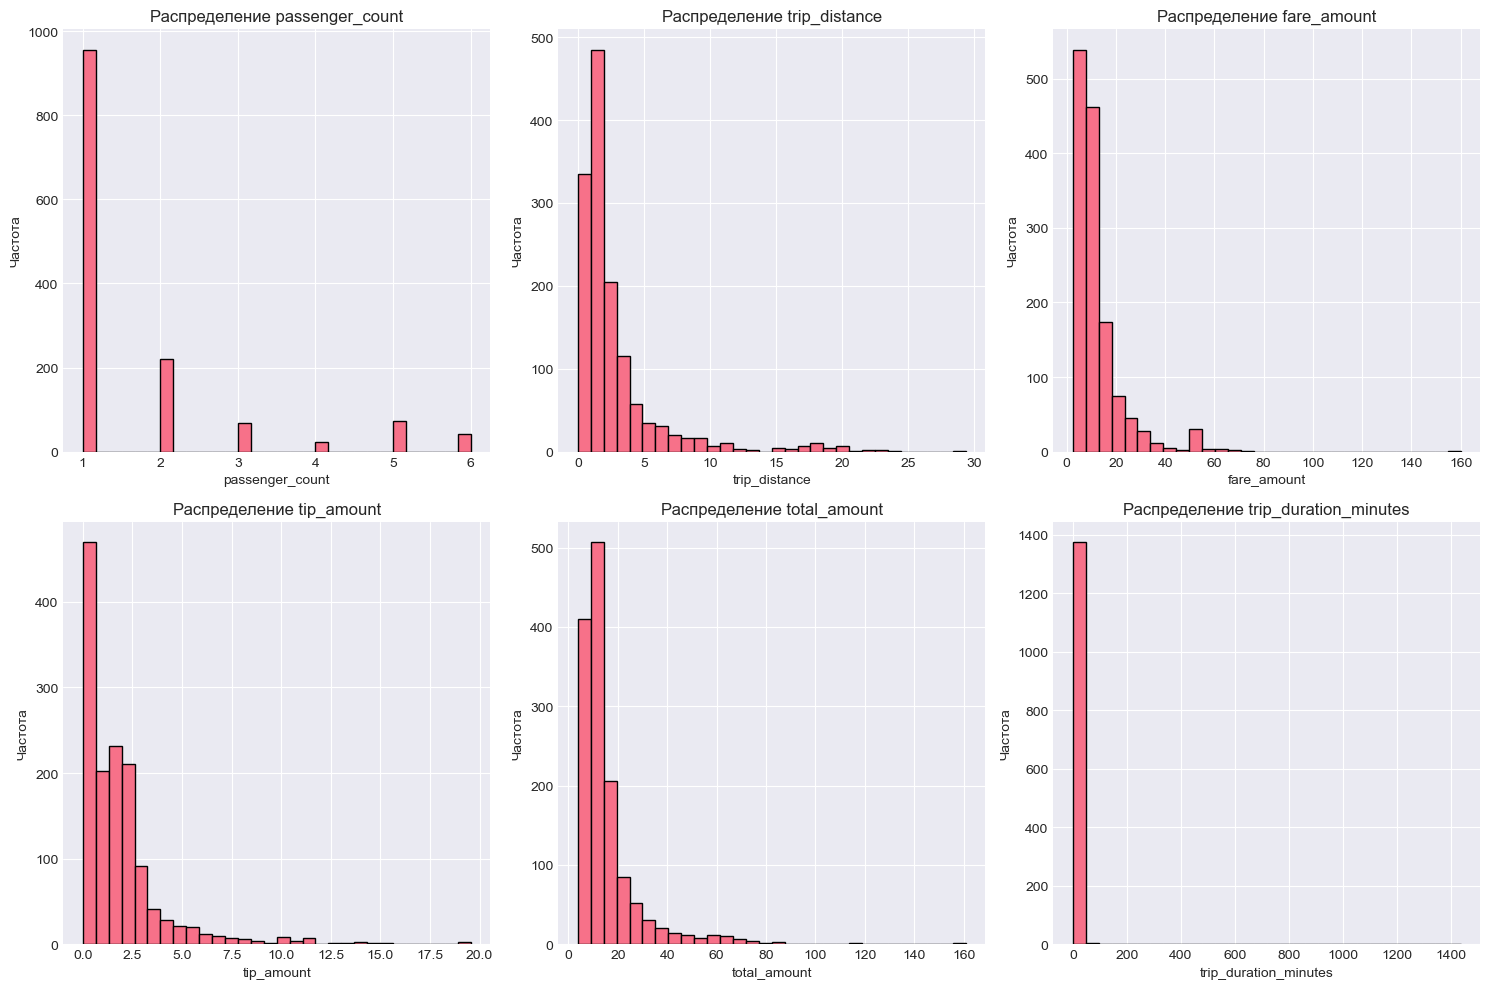

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 
                'tip_amount', 'total_amount', 'trip_duration_minutes']

for i, col in enumerate(numeric_cols):
    row = i // 3
    col_idx = i % 3
    axes[row, col_idx].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[row, col_idx].set_title(f'Распределение {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Ячейка 7: Анализ важности признаков (корреляция)

- Выбираем числовые признаки для корреляции

In [9]:
numeric_features = ['passenger_count', 'trip_distance', 'fare_amount', 
                   'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 
                   'improvement_surcharge', 'total_amount', 'trip_duration_minutes']

- Строим матрицу корреляций

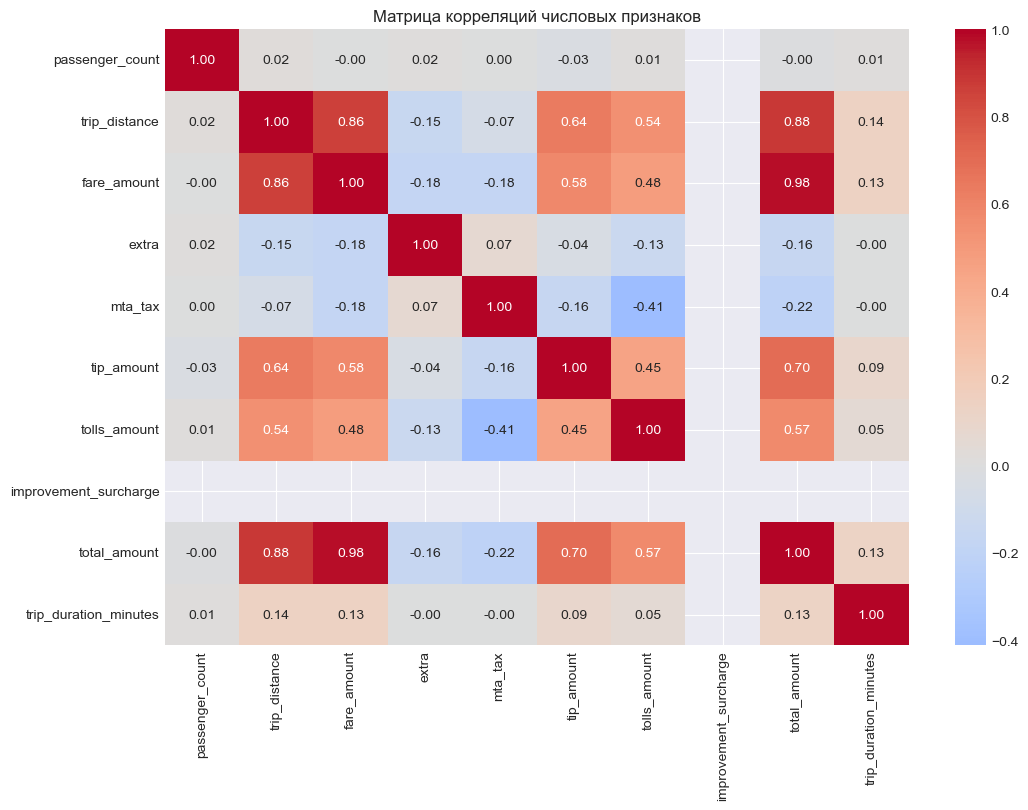

Наиболее важные признаки (сильная корреляция с total_amount):
total_amount             1.000000
fare_amount              0.982985
trip_distance            0.880900
tip_amount               0.700035
tolls_amount             0.574826
trip_duration_minutes    0.133921
passenger_count         -0.004535
extra                   -0.156296
mta_tax                 -0.216365
improvement_surcharge         NaN
Name: total_amount, dtype: float64


In [10]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций числовых признаков')
plt.show()

print("Наиболее важные признаки (сильная корреляция с total_amount):")
corr_with_total = correlation_matrix['total_amount'].sort_values(ascending=False)
print(corr_with_total)

# Ячейка 8: Анализ по часам

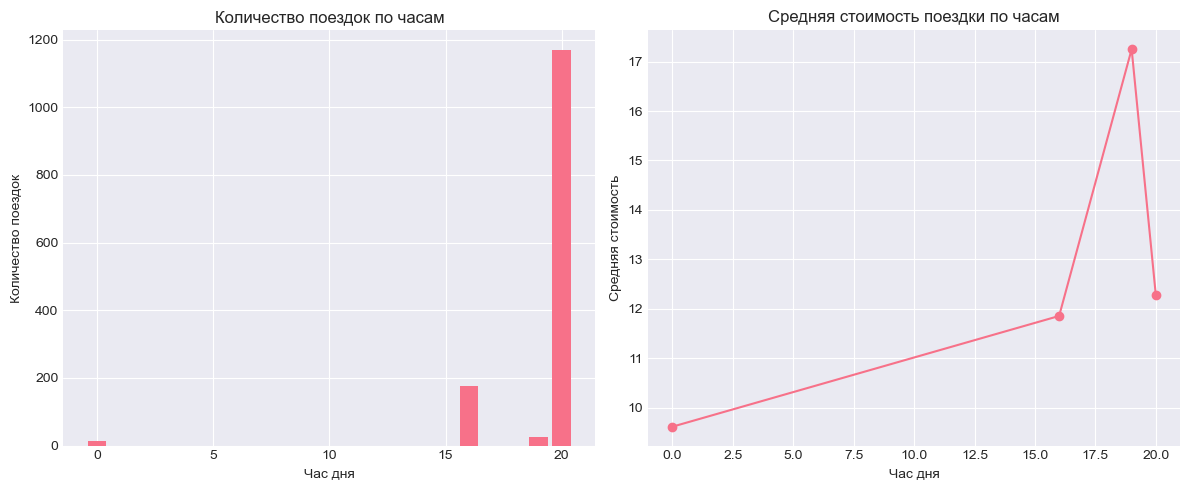

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
hourly_trips = df['pickup_hour'].value_counts().sort_index()
plt.bar(hourly_trips.index, hourly_trips.values)
plt.title('Количество поездок по часам')
plt.xlabel('Час дня')
plt.ylabel('Количество поездок')

plt.subplot(1, 2, 2)
hourly_fare = df.groupby('pickup_hour')['fare_amount'].mean()
plt.plot(hourly_fare.index, hourly_fare.values, marker='o')
plt.title('Средняя стоимость поездки по часам')
plt.xlabel('Час дня')
plt.ylabel('Средняя стоимость')

plt.tight_layout()
plt.show()

# Ячейка 9: Подготовка данных для кластеризации

- Выбираем признаки для кластеризации

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

features_for_clustering = ['trip_distance', 'fare_amount', 'tip_amount', 
                          'passenger_count', 'trip_duration_minutes']

- Удаляем строки с пропущенными значениями

In [13]:
df_clean = df[features_for_clustering].dropna()

- Масштабируем данные

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("Данные подготовлены для кластеризации. Размер:", X_scaled.shape)

Данные подготовлены для кластеризации. Размер: (1382, 5)


# Ячейка 10: Кластеризация методом K-Means

- Определяем оптимальное количество кластеров

In [15]:
inertia = []
silhouette_scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

- Визуализация для выбора оптимального k

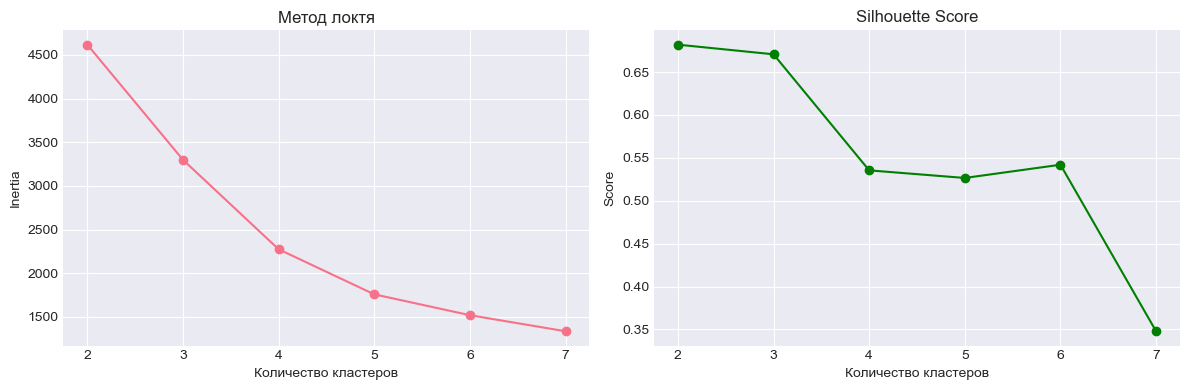

Лучший silhouette score: 0.682 при k=2


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(2, 8), inertia, marker='o')
axes[0].set_title('Метод локтя')
axes[0].set_xlabel('Количество кластеров')
axes[0].set_ylabel('Inertia')

axes[1].plot(range(2, 8), silhouette_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Количество кластеров')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

print(f"Лучший silhouette score: {max(silhouette_scores):.3f} при k={silhouette_scores.index(max(silhouette_scores))+2}")

# Ячейка 11: Применяем K-Means с оптимальным k

In [17]:
optimal_k = 3  # или другое значение на основе графика
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

- Метрики для K-Means

In [18]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"K-Means (k={optimal_k}):")
print(f"Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Davies-Bouldin Index: {kmeans_db:.3f}")

K-Means (k=3):
Silhouette Score: 0.671
Davies-Bouldin Index: 0.591


# Ячейка 12: Кластеризация методом DBSCAN

- Подбираем параметры для DBSCAN

In [19]:
from sklearn.cluster import DBSCAN

eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 7]

best_score = -1
best_params = None
best_labels = None

- Проверяем, что получилось больше одного кластера

In [20]:
print("Поиск оптимальных параметров DBSCAN:")
print("-" * 50)
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        
        
        if n_clusters > 1:
            try:
                score = silhouette_score(X_scaled, labels)
                print(f"eps={eps}, min_samples={min_samples}: {n_clusters} кластеров, {n_noise} шумовых, silhouette={score:.3f}")
                
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_samples)
                    best_labels = labels
            except:
                print(f"eps={eps}, min_samples={min_samples}: ошибка вычисления силуэта")
        else:
            print(f"eps={eps}, min_samples={min_samples}: только 1 кластер или все точки - шум")

print("\n" + "=" * 50)
if best_params:
    print(f"Лучшие параметры DBSCAN: eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"Лучший Silhouette Score: {best_score:.3f}")
else:
    print("Не удалось найти подходящие параметры. Используем значения по умолчанию.")
    best_params = (0.5, 5)

Поиск оптимальных параметров DBSCAN:
--------------------------------------------------
eps=0.3, min_samples=3: 21 кластеров, 160 шумовых, silhouette=0.073
eps=0.3, min_samples=5: 16 кластеров, 210 шумовых, silhouette=0.080
eps=0.3, min_samples=7: 11 кластеров, 265 шумовых, silhouette=0.078
eps=0.5, min_samples=3: 15 кластеров, 84 шумовых, silhouette=0.107
eps=0.5, min_samples=5: 8 кластеров, 121 шумовых, silhouette=0.141
eps=0.5, min_samples=7: 7 кластеров, 139 шумовых, silhouette=0.141
eps=0.7, min_samples=3: 11 кластеров, 62 шумовых, silhouette=0.139
eps=0.7, min_samples=5: 8 кластеров, 76 шумовых, silhouette=0.162
eps=0.7, min_samples=7: 7 кластеров, 98 шумовых, silhouette=0.139
eps=1.0, min_samples=3: 5 кластеров, 29 шумовых, silhouette=0.557
eps=1.0, min_samples=5: 3 кластеров, 40 шумовых, silhouette=0.663
eps=1.0, min_samples=7: 3 кластеров, 45 шумовых, silhouette=0.664

Лучшие параметры DBSCAN: eps=1.0, min_samples=7
Лучший Silhouette Score: 0.664


# Ячейка 13: Применяем DBSCAN с лучшими параметрами 

- Если best_params не определен, используем значения по умолчанию

In [21]:
if best_params:
    dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
    dbscan_labels = dbscan.fit_predict(X_scaled)
else:
    print("Используем параметры по умолчанию: eps=0.5, min_samples=5")
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nРЕЗУЛЬТАТЫ DBSCAN:")
print("=" * 50)
print(f"Количество кластеров: {n_clusters_dbscan}")
print(f"Количество шумовых точек: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    print(f"Silhouette Score: {dbscan_silhouette:.3f}")
else:
    print("Silhouette Score: невозможно вычислить (меньше 2 кластеров)")


РЕЗУЛЬТАТЫ DBSCAN:
Количество кластеров: 3
Количество шумовых точек: 45 (3.3%)
Silhouette Score: 0.664


# Ячейка 14: Иерархическая кластеризация

In [22]:
agglo = AgglomerativeClustering(n_clusters=optimal_k)
agglo_labels = agglo.fit_predict(X_scaled)

agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
agglo_db = davies_bouldin_score(X_scaled, agglo_labels)

print(f"Иерархическая кластеризация (k={optimal_k}):")
print(f"Silhouette Score: {agglo_silhouette:.3f}")
print(f"Davies-Bouldin Index: {agglo_db:.3f}")

Иерархическая кластеризация (k=3):
Silhouette Score: 0.577
Davies-Bouldin Index: 0.713


# Ячейка 15: Сравнение методов кластеризации

In [23]:
print("СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:")
print("-" * 50)
print(f"{'Метод':<20} {'Silhouette':<15} {'Davies-Bouldin':<15}")
print("-" * 50)
print(f"{'K-Means':<20} {kmeans_silhouette:<15.3f} {kmeans_db:<15.3f}")
print(f"{'DBSCAN':<20} {silhouette_score(X_scaled, dbscan_labels):<15.3f} {'N/A':<15}")
print(f"{'Hierarchical':<20} {agglo_silhouette:<15.3f} {agglo_db:<15.3f}")

СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:
--------------------------------------------------
Метод                Silhouette      Davies-Bouldin 
--------------------------------------------------
K-Means              0.671           0.591          
DBSCAN               0.664           N/A            
Hierarchical         0.577           0.713          


# Ячейка 16: Визуализация кластеров (PCA) - исправленная

- Уменьшаем размерность для визуализации

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

- Визуализация для каждого метода

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

- K-Means

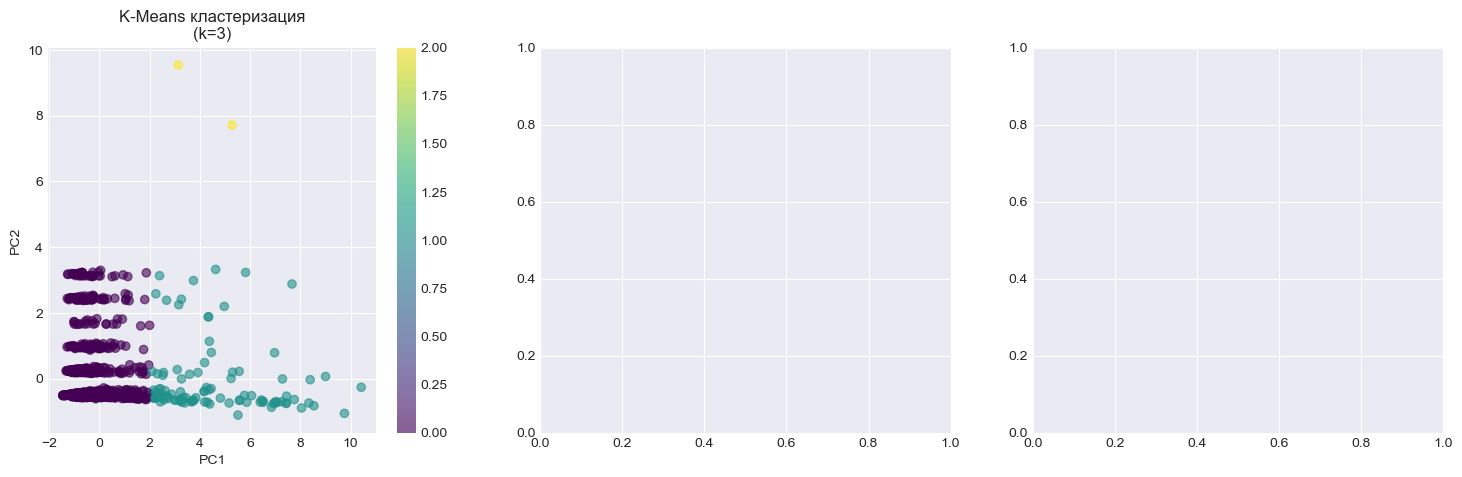

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
axes[0].set_title(f'K-Means кластеризация\n(k={optimal_k})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])
plt.show()

- DBSCAN

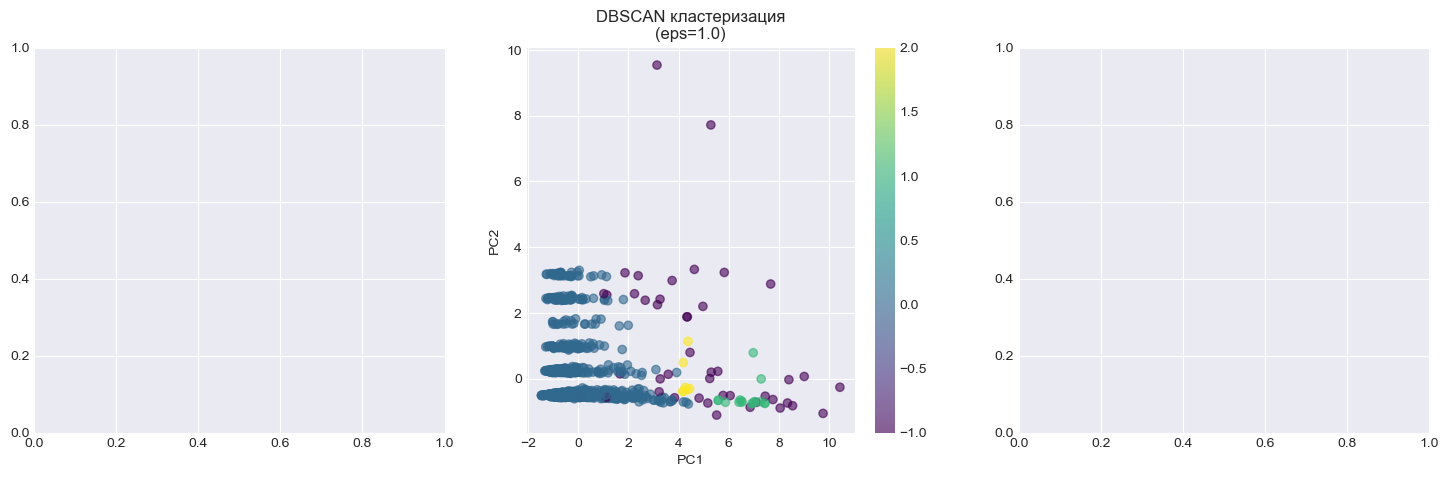

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6)
axes[1].set_title(f'DBSCAN кластеризация\n(eps={best_params[0] if best_params else 0.5})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])
plt.show()

- Hierarchical

Объясненная дисперсия PCA: 68.54%


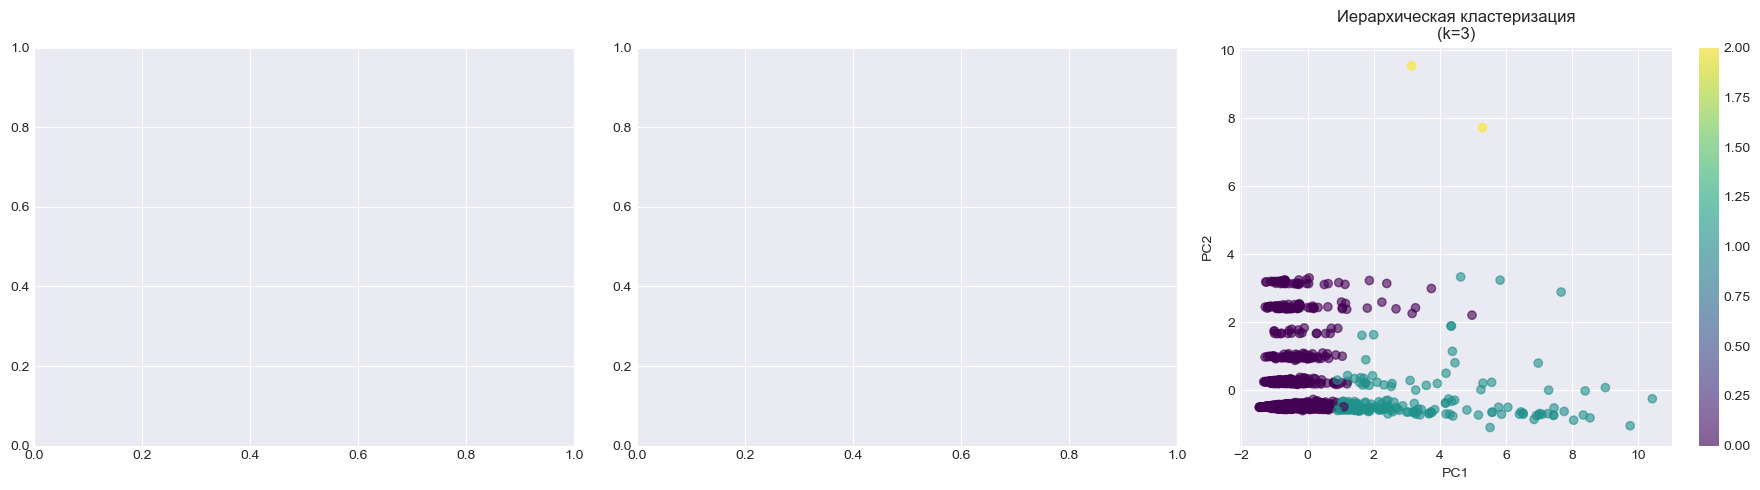

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='viridis', alpha=0.6)
axes[2].set_title(f'Иерархическая кластеризация\n(k={optimal_k})')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()

print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")
plt.show()

# Ячейка 17: Описание кластеров (для K-Means)

- Добавляем метки кластеров в исходный DataFrame

In [55]:
df_clustered = df_clean.copy()
df_clustered['Cluster'] = kmeans_labels

- Описание кластеров

In [56]:
print("ОПИСАНИЕ КЛАСТЕРОВ (K-Means):")
print("=" * 60)

for cluster in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster]
    print(f"\nКластер {cluster}:")
    print(f"Размер: {len(cluster_data)} поездок ({len(cluster_data)/len(df_clustered)*100:.1f}%)")
    print("\nСредние значения:")
    print(cluster_data[features_for_clustering].mean().round(2))
    print("\nМедианные значения:")
    print(cluster_data[features_for_clustering].median().round(2))
    print("-" * 40)

ОПИСАНИЕ КЛАСТЕРОВ (K-Means):

Кластер 0:
Размер: 1275 поездок (92.3%)

Средние значения:
trip_distance             2.02
fare_amount               9.93
tip_amount                1.33
passenger_count           1.67
trip_duration_minutes    11.12
dtype: float64

Медианные значения:
trip_distance             1.57
fare_amount               8.50
tip_amount                1.26
passenger_count           1.00
trip_duration_minutes    10.00
dtype: float64
----------------------------------------

Кластер 1:
Размер: 105 поездок (7.6%)

Средние значения:
trip_distance            12.86
fare_amount              40.87
tip_amount                6.78
passenger_count           1.70
trip_duration_minutes    32.06
dtype: float64

Медианные значения:
trip_distance            11.23
fare_amount              36.00
tip_amount                6.65
passenger_count           1.00
trip_duration_minutes    33.00
dtype: float64
----------------------------------------

Кластер 2:
Размер: 2 поездок (0.1%)

Средние зн

# Ячейка 18: Визуализация характеристик кластеров

- Берем первые 5 признаков

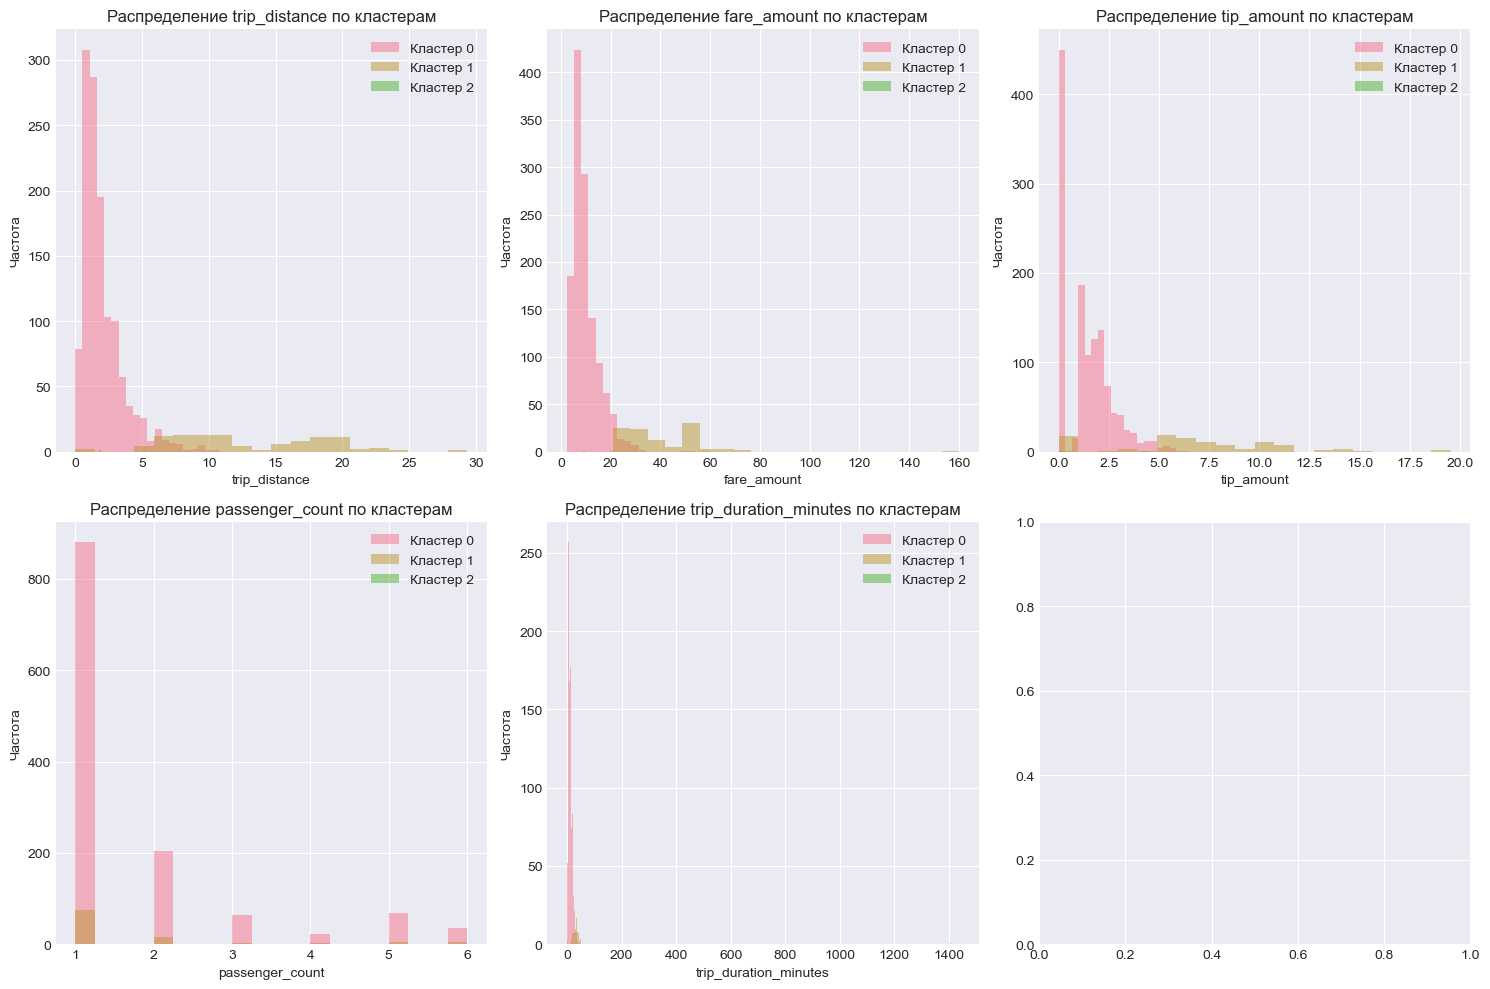

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feature in enumerate(features_for_clustering[:5]): 
    row = i // 3
    col = i % 3
    
    for cluster in range(optimal_k):
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster][feature]
        axes[row, col].hist(cluster_data, alpha=0.5, label=f'Кластер {cluster}', bins=20)
    
    axes[row, col].set_title(f'Распределение {feature} по кластерам')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Частота')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

# Ячейка 19: Подготовка данных для классификации

- Создаем целевую переменную (например, размер чаевых)

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

df['tip_category'] = pd.cut(df['tip_amount'], 
                            bins=[-1, 0, 2, 5, 100], 
                            labels=['no_tip', 'small_tip', 'medium_tip', 'large_tip'])

- Выбираем признаки для классификации

In [59]:
feature_cols = ['passenger_count', 'trip_distance', 'fare_amount', 
                'pickup_hour', 'pickup_weekday', 'trip_duration_minutes']

- Удаляем строки с пропущенными значениями

In [60]:
df_class = df[feature_cols + ['tip_category']].dropna()

- Разделяем на признаки и целевую переменную

In [61]:
X = df_class[feature_cols]
y = df_class['tip_category']

- Кодируем целевую переменную

In [62]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

- Разделяем на обучающую и тестовую выборки

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Классы: {le.classes_}")

Размер обучающей выборки: (1105, 6)
Размер тестовой выборки: (277, 6)
Классы: ['large_tip' 'medium_tip' 'no_tip' 'small_tip']


# Ячейка 20: Модель 1 - Decision Tree

- Предсказание

In [64]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

- Метрики

In [65]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("ДЕРЕВО РЕШЕНИЙ:")
print(f"Accuracy: {dt_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=le.classes_))

ДЕРЕВО РЕШЕНИЙ:
Accuracy: 0.502

Classification Report:
              precision    recall  f1-score   support

   large_tip       0.45      0.88      0.60        17
  medium_tip       0.46      0.68      0.55        65
      no_tip       0.22      0.04      0.07        94
   small_tip       0.58      0.75      0.66       101

    accuracy                           0.50       277
   macro avg       0.43      0.59      0.47       277
weighted avg       0.42      0.50      0.43       277



- Матрица ошибок

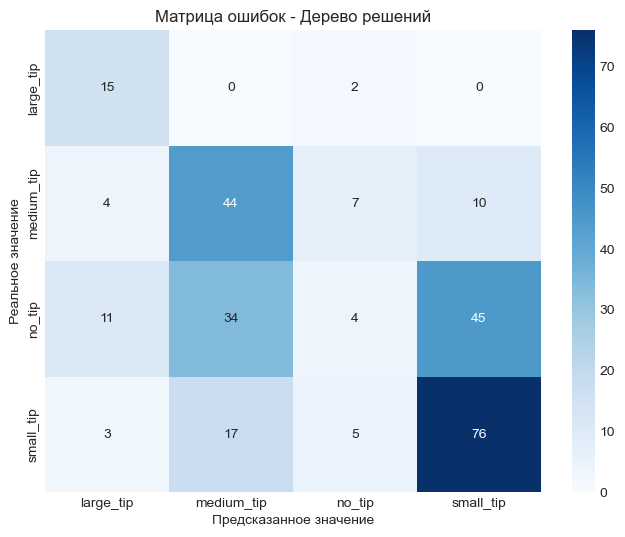

In [66]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок - Дерево решений')
plt.ylabel('Реальное значение')
plt.xlabel('Предсказанное значение')
plt.show()

# Ячейка 21: Модель 2 - Random Forest

- Предсказание

In [67]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

- Метрики

In [68]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("СЛУЧАЙНЫЙ ЛЕС:")
print(f"Accuracy: {rf_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

СЛУЧАЙНЫЙ ЛЕС:
Accuracy: 0.462

Classification Report:
              precision    recall  f1-score   support

   large_tip       0.52      0.71      0.60        17
  medium_tip       0.45      0.57      0.50        65
      no_tip       0.27      0.15      0.19        94
   small_tip       0.55      0.64      0.59       101

    accuracy                           0.46       277
   macro avg       0.45      0.52      0.47       277
weighted avg       0.43      0.46      0.43       277



- Матрица ошибок

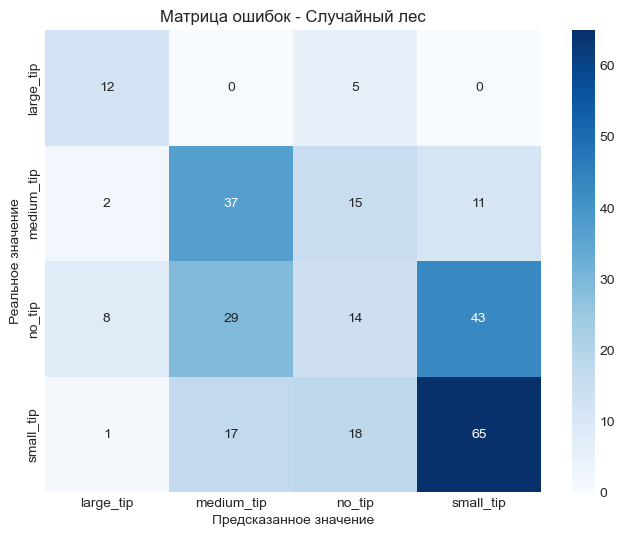

In [69]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок - Случайный лес')
plt.ylabel('Реальное значение')
plt.xlabel('Предсказанное значение')
plt.show()

- Важность признаков

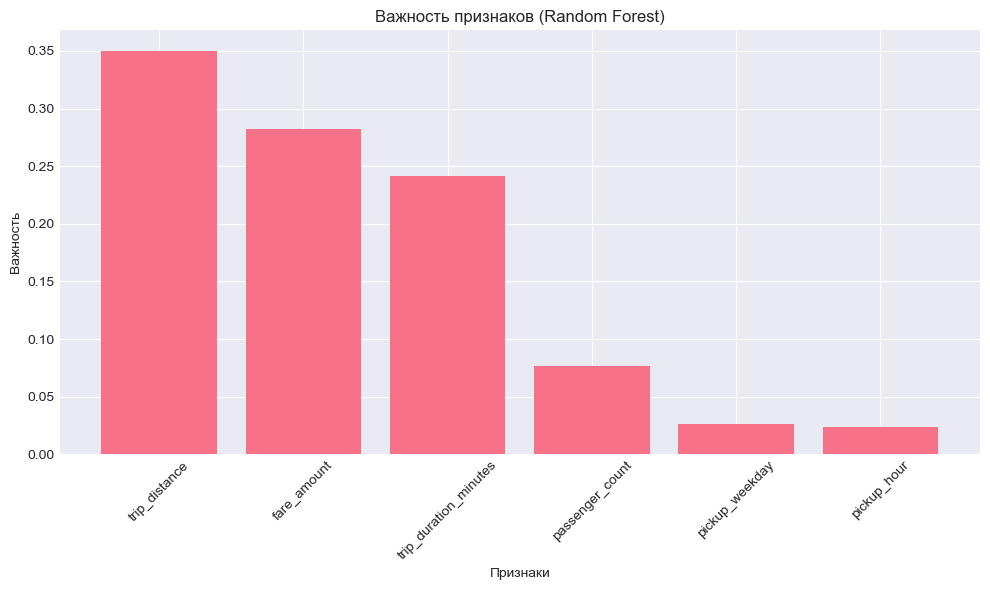

In [70]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ячейка 22: Модель 3 - Gradient Boosting

- Предсказание

In [71]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=3)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

- Метрики

In [72]:
gb_accuracy = accuracy_score(y_test, gb_pred)

print("GRADIENT BOOSTING:")
print(f"Accuracy: {gb_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, gb_pred, target_names=le.classes_))

GRADIENT BOOSTING:
Accuracy: 0.484

Classification Report:
              precision    recall  f1-score   support

   large_tip       0.43      0.53      0.47        17
  medium_tip       0.48      0.63      0.55        65
      no_tip       0.32      0.19      0.24        94
   small_tip       0.58      0.65      0.61       101

    accuracy                           0.48       277
   macro avg       0.45      0.50      0.47       277
weighted avg       0.46      0.48      0.46       277



- Матрица ошибок

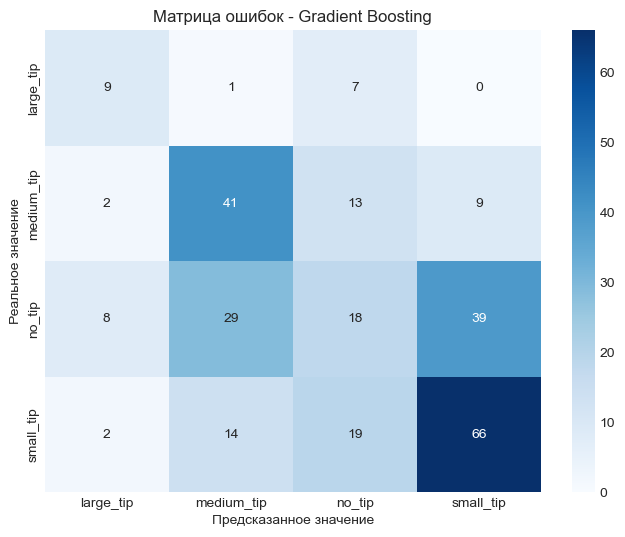

In [73]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок - Gradient Boosting')
plt.ylabel('Реальное значение')
plt.xlabel('Предсказанное значение')
plt.show()

# Ячейка 23: Сравнение моделей классификации

- Отображение

In [74]:
print("СРАВНЕНИЕ МОДЕЛЕЙ КЛАССИФИКАЦИИ:")
print("=" * 50)
print(f"{'Модель':<20} {'Accuracy':<15}")
print("-" * 50)
print(f"{'Decision Tree':<20} {dt_accuracy:<15.3f}")
print(f"{'Random Forest':<20} {rf_accuracy:<15.3f}")
print(f"{'Gradient Boosting':<20} {gb_accuracy:<15.3f}")

СРАВНЕНИЕ МОДЕЛЕЙ КЛАССИФИКАЦИИ:
Модель               Accuracy       
--------------------------------------------------
Decision Tree        0.502          
Random Forest        0.462          
Gradient Boosting    0.484          


- Визуализация сравнения

In [75]:
models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
accuracies = [dt_accuracy, rf_accuracy, gb_accuracy]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1)
plt.title('Сравнение точности моделей классификации')
plt.ylabel('Accuracy')
plt.xlabel('Модель')

Text(0.5, 0, 'Модель')

- Добавляем значения на столбцы

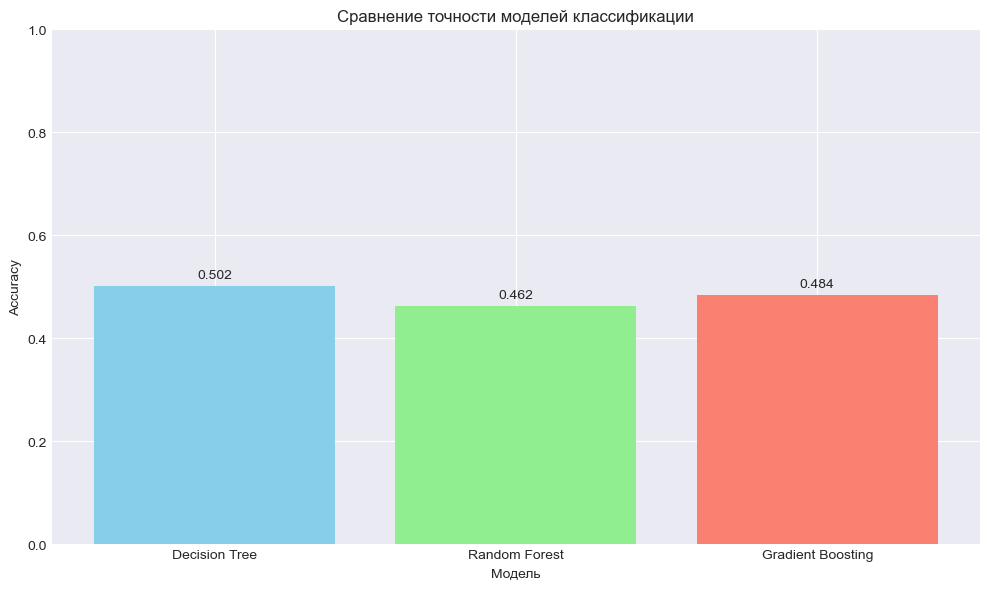

In [76]:
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Ячейка 24: Сохранение лучшей модели

- Выбираем лучшую модель (например, Random Forest)

In [77]:
best_model = rf_model

- Сохраняем модель

In [78]:
joblib.dump(best_model, 'best_taxi_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Модель сохранена как 'best_taxi_model.pkl'")
print("Scaler сохранен как 'scaler.pkl'")
print("Label encoder сохранен как 'label_encoder.pkl'")

Модель сохранена как 'best_taxi_model.pkl'
Scaler сохранен как 'scaler.pkl'
Label encoder сохранен как 'label_encoder.pkl'


- Пример загрузки и использования модели

In [79]:
print("\nПример загрузки модели:")
loaded_model = joblib.load('best_taxi_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_le = joblib.load('label_encoder.pkl')
print("Модель успешно загружена!")


Пример загрузки модели:
Модель успешно загружена!


# Ячейка 25: Тестирование модели на новых данных

- Создаем пример новых данных

In [80]:
new_trip = pd.DataFrame({
    'passenger_count': [2],
    'trip_distance': [5.5],
    'fare_amount': [18.5],
    'pickup_hour': [14],
    'pickup_weekday': [3],
    'trip_duration_minutes': [25]
})

- Предсказание

In [81]:
prediction = best_model.predict(new_trip)
predicted_category = le.inverse_transform(prediction)

print("Тестирование на новых данных:")
print(f"Данные поездки: {new_trip.iloc[0].to_dict()}")
print(f"Предсказанная категория чаевых: {predicted_category[0]}")

Тестирование на новых данных:
Данные поездки: {'passenger_count': 2.0, 'trip_distance': 5.5, 'fare_amount': 18.5, 'pickup_hour': 14.0, 'pickup_weekday': 3.0, 'trip_duration_minutes': 25.0}
Предсказанная категория чаевых: medium_tip


## DataLens

### https://datalens.ru/zyn4gyadmaumj